# Introdução



# Objetivos

* Considerando os dados do CEMADEN, fazer um modelo que é capaz de prever eventos com chamados.

# TODO

* [X] Verificar diferença entre conjunto de validação aleatório vs por ano
* [X] Variar métricas de agregados
* [X] Variar métricas de agregados
* [X] Clusterizar para verificar relação entre pontos com enchente e sem. (plotly scatter 3D)
* [x] Undersampling com k alto
* [x] Agregado de média de maiores estações

Foco
* []  Coagir chamados para dias com chuvas acima do normal (testar vários recortes)
  * [] Testar clusterização para verificar "fake trues"
  * [] Recorte por percentil de chuva (começar pelos casos mais extremos)
* [] Coagir dias com pouca chuva e chamado para não ter chamado (testar vários recortes)

P/ depois
* [] Confirmar estações para cada bacia (olhar nos mapas)
* [] Testar modelos específicos para outras bacias (além de Tam.)
* [] Definição de chuva de alto risco E

# Importa libs e define funções

In [1]:
# Pycaret
!pip install --upgrade packaging -q
!pip install pycaret[full] -q

from pycaret.classification import *

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

In [ ]:
# File management
import zipfile
import gdown
import os
import numpy as np

# Data manipulation
import pandas as pd

# Data splitting
from sklearn.model_selection import train_test_split

# Sampling techniques
from imblearn.under_sampling import ClusterCentroids

# Plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [ ]:
def grab_from_gdrive(file_id, filename):
  parent_dir = '/content'
  url = f"https://drive.google.com/uc?id={file_id}"
  output = os.path.join(parent_dir, filename)
  if not(os.path.isfile(output)):
    gdown.download(url, output=output, quiet=False)

In [ ]:
def cluster_undersample(df, target_column, resample_strength, samples_per_cluster):
    """
    Performs undersampling on the majority class (assumed False) using KMeans clustering.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_column (str): The name of the target column (boolean).
        resample_proportion (float): The desired proportion of the minority class
                                     (True) in the resampled dataset (between 0 and 1).
        samples_per_cluster (int): The number of samples to take from each cluster
                                   of the majority class.

    Returns:
        pd.DataFrame: The resampled DataFrame.
    """
    df_true = df[df[target_column] == True].copy()
    df_false = df[df[target_column] == False].copy()

    # Calculate the number of true instances
    num_true = len(df_true)
    num_false = len(df_false)

    desired_num_false = int(num_false / resample_strength)
    num_clusters = max(1, int(desired_num_false / samples_per_cluster))

    print(f"Number of true instances: {num_true}")
    print(f"Desired number of false instances: {desired_num_false}")
    print(f"Calculated number of clusters: {num_clusters}")
    print(f"Samples per cluster: {samples_per_cluster}")

    if num_clusters > len(df_false):
        print(f"Warning: Calculated number of clusters ({num_clusters}) is greater than the number of false instances ({len(df_false)}). Setting number of clusters to the number of false instances.")
        num_clusters = len(df_false)
        samples_per_cluster = 1 # Adjust samples per cluster to avoid errors

    if num_clusters == 0:
        print("Warning: No clusters will be created as the desired number of false instances is 0.")
        return df_true

    # Apply KMeans clustering to the majority class
    # Exclude non-numeric columns like 'dt' if it exists
    feature_columns = df_false.select_dtypes(include=np.number).columns
    if 'dt' in df_false.columns:
        feature_columns = feature_columns.drop('dt', errors='ignore')
    if target_column in feature_columns:
        feature_columns = feature_columns.drop(target_column, errors='ignore')


    if len(feature_columns) == 0:
         raise ValueError("No numeric features available for clustering.")


    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(df_false[feature_columns])
    df_false['cluster'] = kmeans.labels_

    # Sample from each cluster
    df_false_resampled = pd.DataFrame()
    for cluster_label in range(num_clusters):
        cluster_data = df_false[df_false['cluster'] == cluster_label]
        if not cluster_data.empty:
            # Sample min(samples_per_cluster, actual number of samples in cluster)
            sampled_cluster_data = cluster_data.sample(n=min(samples_per_cluster, len(cluster_data)), random_state=42)
            df_false_resampled = pd.concat([df_false_resampled, sampled_cluster_data], ignore_index=True)

    # Combine the resampled majority class with the minority class
    df_resampled = pd.concat([df_true, df_false_resampled.drop(columns=['cluster'], errors='ignore')], ignore_index=True)

    return df_resampled

# Carrega dados CEMADEN

* Carrega dados do google drive com daily metrics

In [ ]:
file_agregado_cemaden = 'df_daily_metrics.csv'
grab_from_gdrive('1wYMSPeli7S2QiZQl0WJR4r3E7u41hQRZ', file_agregado_cemaden)
df_daily_metrics = pd.read_csv(file_agregado_cemaden)

# Carrega datas de enchentes verificadas

In [ ]:
file_enchentes = 'df_enchentes_verificados.csv'
grab_from_gdrive('1GDKraiiulvZ0_H-SWMiN76GnDn9lE_9T', file_enchentes)
df_enchentes_verificados = pd.read_csv(file_enchentes)

Downloading...
From: https://drive.google.com/uc?id=1GDKraiiulvZ0_H-SWMiN76GnDn9lE_9T
To: /content/df_enchentes_verificados.csv
100%|██████████| 2.05k/2.05k [00:00<00:00, 4.09MB/s]


# Faz o merge dos datasets

* Agrega dados de chuva por data pela soma, remove colunas em que essa agregação não faz sentido
* Remove meses tipicamente sem chuva (entre 5 e 10)
* Adiciona coluna de enchente, verificando se houve enchente no dataset de enchentes

In [ ]:
df_dm_grouped = df_daily_metrics.groupby(["ano", "mes", "dia"]).sum().reset_index()
df_dm_grouped.drop(columns=["latitude", "longitude", "coef_var", "perc_chuva_em_3h", "nomeEstacao"], inplace=True)

In [ ]:
df_dm_dt = df_dm_grouped.copy()
df_dm_dt['dt'] = pd.to_datetime(df_dm_dt.apply(lambda row: f"{int(row['dia']):02}/{int(row['mes']):02}/{int(row['ano'])}", axis=1), dayfirst=True)
df_dm_dt.drop(columns=["ano", "mes", "dia"], inplace=True)

In [ ]:
df_dm_sazonal = df_dm_dt[~df_dm_dt["dt"].dt.month.between(5, 10)].copy()

In [ ]:
df_dm_enchentes = df_dm_sazonal.copy()
df_dm_enchentes['enchente'] = df_dm_enchentes['dt'].isin(df_enchentes_verificados['dt'])

# Testa com configuração padrão

* Modelo com chamados novos
* Usa dataset CEMADEN
* Sem rebalanceamento

Melhores modelos obtidos:

| Model | Description                    | Accuracy |   AUC   | Recall | Prec. |   F1   | Kappa  |  MCC   | TT (Sec) |
|-------|--------------------------------|----------|--------|--------|-------|--------|--------|--------|----------|
| qda   | Quadratic Discriminant Analysis| 0.9209   | 0.8127 | 0.4491 | 0.2991| **0.3540** | **0.3150** | 0.3246 | 0.0280   |
| nb    | Naive Bayes                    | 0.9130   | 0.8172 | **0.4709** | 0.2744| 0.3440 | 0.3023 | 0.3157 | 0.0240   |
| lda   | Linear Discriminant Analysis   | **0.9403** | **0.8284** | 0.3182 | **0.3488**| 0.3307 | 0.2997 | **0.3011** | **0.0240**   |

Os modelos que aparecem aí são modelos resistentes a desbalanceamento, mas mesmo eles estão com característica de modelo desbalanceado. Não faz sentido continuar sem balanceamento.

In [ ]:
X = df_dm_enchentes.drop(columns=["dt", "enchente"])
y = df_dm_enchentes["enchente"]

In [ ]:
s = setup(data=X, target=y, session_id=123, fix_imbalance=False, fold=5, imputation_type=None)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(1626, 6)"
4,Transformed data shape,"(1626, 6)"
5,Transformed train set shape,"(1138, 6)"
6,Transformed test set shape,"(488, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9209,0.8127,0.4491,0.2991,0.3540,0.3150,0.3246,0.0280
nb,Naive Bayes,0.9130,0.8172,0.4709,0.2744,0.3440,0.3023,0.3157,0.0240
lda,Linear Discriminant Analysis,0.9403,0.8284,0.3182,0.3488,0.3307,0.2997,0.3011,0.0240
rf,Random Forest Classifier,0.9578,0.7904,0.2091,0.7690,0.3095,0.2950,0.3688,0.2860
dt,Decision Tree Classifier,0.9341,0.6145,0.3000,0.3213,0.3000,0.2668,0.2716,0.0460
et,Extra Trees Classifier,0.9561,0.8073,0.1891,0.6690,0.2762,0.2612,0.3228,0.1900
gbc,Gradient Boosting Classifier,0.9490,0.7784,0.2073,0.4452,0.2713,0.2488,0.2731,0.2020
knn,K Neighbors Classifier,0.9561,0.7146,0.1691,0.7167,0.2587,0.2444,0.3192,0.1380
xgboost,Extreme Gradient Boosting,0.9473,0.7587,0.2073,0.3783,0.2585,0.2348,0.2502,0.1000
lightgbm,Light Gradient Boosting Machine,0.9499,0.7725,0.1909,0.5238,0.2561,0.2354,0.2744,0.9440


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

# Testa com rebalanceamento

* Testa todas as técnicas de rebalanceamento do pycaret

In [ ]:
X = df_dm_enchentes.drop(columns=["dt", "enchente"])
y = df_dm_enchentes["enchente"]

In [ ]:
# Undersample the training data using Cluster Centroids
cc = ClusterCentroids(random_state=42, sampling_strategy=1)
X_resampled, y_resampled = cc.fit_resample(X, y)

In [ ]:
setup(data=X, target=y, session_id=123, fix_imbalance=True, fix_imbalance_method="svmsmote", fold=5, imputation_type=None)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(1626, 6)"
4,Transformed data shape,"(2658, 6)"
5,Transformed train set shape,"(2170, 6)"
6,Transformed test set shape,"(488, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9280,0.8227,0.4909,0.3201,0.3872,0.3507,0.3600,0.0520
ada,Ada Boost Classifier,0.9174,0.8109,0.4909,0.3005,0.3672,0.3274,0.3410,0.1560
et,Extra Trees Classifier,0.9403,0.8061,0.3764,0.3686,0.3670,0.3362,0.3389,0.2160
qda,Quadratic Discriminant Analysis,0.9139,0.7925,0.4873,0.2729,0.3481,0.3065,0.3220,0.0680
rf,Random Forest Classifier,0.9367,0.7899,0.3600,0.3284,0.3402,0.3074,0.3093,0.4120
ridge,Ridge Classifier,0.9315,0.8288,0.3782,0.3018,0.3345,0.2989,0.3017,0.0380
nb,Naive Bayes,0.9033,0.8213,0.4909,0.2540,0.3321,0.2876,0.3062,0.0360
lda,Linear Discriminant Analysis,0.9271,0.8288,0.3782,0.2801,0.3213,0.2836,0.2875,0.0360
gbc,Gradient Boosting Classifier,0.9271,0.8026,0.3764,0.2836,0.3211,0.2836,0.2880,0.2680
lightgbm,Light Gradient Boosting Machine,0.9253,0.7594,0.3800,0.2799,0.3201,0.2818,0.2867,0.7300


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9298,0.7868,0.4545,0.3333,0.3846,0.3483,0.3531
1,0.9254,0.8006,0.3636,0.2857,0.3200,0.2812,0.2834
2,0.9123,0.7625,0.4545,0.2632,0.3333,0.2899,0.3024
3,0.9604,0.8251,0.4000,0.5714,0.4706,0.4507,0.4584
4,0.9427,0.7408,0.3000,0.3333,0.3158,0.2860,0.2864
Mean,0.9341,0.7831,0.3945,0.3574,0.3649,0.3312,0.3367
Std,0.0163,0.0293,0.0585,0.1104,0.0583,0.0645,0.0658


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)

In [ ]:
predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7174,0.7164,0.6957,0.7273,0.7111,0.4348,0.4352


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label,prediction_score
72,933.320007,638.729980,803.429993,127.000000,34.000000,False,0,0.9254
55,148.662308,48.124615,76.139229,257.076935,0.384615,False,0,0.9586
111,213.259995,181.440002,196.050003,36.000000,8.000000,True,1,0.9756
28,527.726013,270.708008,428.828003,194.600006,12.200000,False,0,0.8154
85,470.559998,299.940002,433.910004,98.000000,20.000000,True,1,0.8125
2,755.510010,578.494995,719.090027,122.000000,26.500000,False,0,0.9394
93,596.770020,247.320007,441.529999,166.000000,23.000000,True,1,0.5833
77,112.779999,20.860001,38.349998,192.000000,0.000000,True,1,0.9295
39,608.960022,313.073334,491.753326,188.666672,16.000000,False,0,0.7178
48,427.523346,58.006668,121.533333,597.666687,0.333333,False,0,0.7922


In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Testa com undersampling por clusters

* Validar com dados de 2023 e 2024
* Clusteriza e pega 20 valores reais de cada cluster (não centróide)
* Pycaret sem conjunto de validação

Melhor modelo (DT classifier):

| **Fold** | **Accuracy** |   **AUC**  | **Recall** |  **Prec.** |   **F1**   |  **Kappa**  |   **MCC**   |
| :------: | :----------: | :--------: | :--------: | :--------: | :--------: | :---------: | :---------: |
|     0    |    0.3673    |   0.3838   |   0.5455   |   0.3636   |   0.4364   |   -0.2220   |   -0.2464   |
|     1    |    0.4583    |   0.4685   |   0.5909   |   0.4333   |   0.5000   |   -0.0612   |   -0.0648   |
|     2    |    0.3958    |   0.3995   |   0.4286   |   0.3462   |   0.3830   |   -0.1959   |   -0.2002   |
| **Mean** |  **0.4072**  | **0.4173** | **0.5216** | **0.3810** | **0.4398** | **-0.1597** | **-0.1705** |
|  **Std** |    0.0380    |   0.0368   |   0.0684   |   0.0377   |   0.0478   |    0.0705   |    0.0771   |


Matriz de confusão p/ dados de teste:

| **True Class \ Predicted Class** | **False** | **True** |
| -------------------------------- | :-------: | :------: |
| **False**                        |    195    |    157   |
| **True**                         |     9     |     2    |


In [ ]:
df_test = df_dm_enchentes[df_dm_enchentes['dt'].dt.year >= 2023]
df_train = df_dm_enchentes[df_dm_enchentes['dt'].dt.year < 2023]

,count
enchente,
False,1198
True,65


In [ ]:
df_train_true = df_train[df_train.enchente == True]

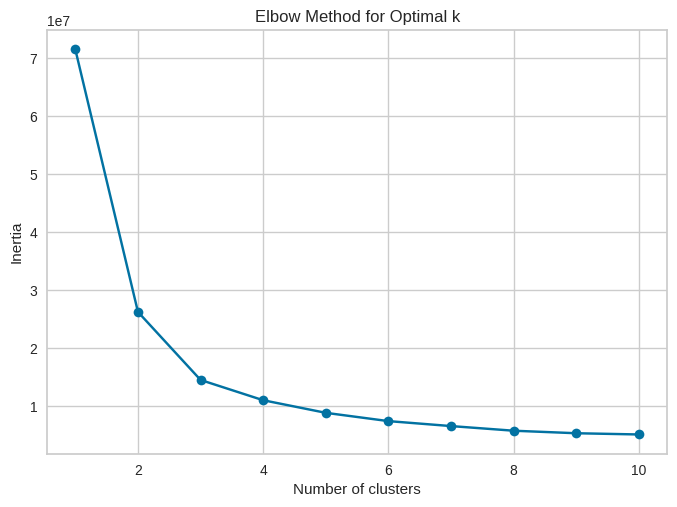

In [ ]:
# prompt: for df_train_false clusterize the dataset and grab 20 random samples from each cluster to add to df_train_resampled, that has all the random picked False data and all the rows where enchente is True. If there is a way to decide automatically the number of clusters, do it

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine optimal number of clusters using Elbow method
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_train_false.drop(columns=['dt', 'enchente']))
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
# Choose the optimal number of clusters (e.g., based on the elbow point)
optimal_k = 4 # Replace with your choice based on the elbow method plot

# Apply KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(df_train_false.drop(columns=['dt', 'enchente']))
df_train_false['cluster'] = kmeans.labels_

df_train_resampled = df_train[df_train.enchente == True].copy()

# Grab 20 random samples from each cluster
for cluster in range(optimal_k):
    cluster_samples = df_train_false[df_train_false['cluster'] == cluster]
    samples_to_add = cluster_samples.sample(n=min(20, len(cluster_samples)), random_state=42)
    df_train_resampled = pd.concat([df_train_resampled, samples_to_add])

# Remove the cluster column
df_train_resampled = df_train_resampled.drop(columns=['cluster'], errors='ignore')

In [ ]:
df_train_resampled.enchente.value_counts()

,count
enchente,
False,80
True,65


In [ ]:
X = df_train_resampled.drop(columns=["dt"])
X_test = df_test.drop(columns=["dt"])

In [ ]:
setup(data=X, target="enchente", session_id=123, fix_imbalance=False, fold=3, imputation_type=None, test_data=X_test)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(508, 6)"
4,Transformed data shape,"(508, 6)"
5,Transformed train set shape,"(145, 6)"
6,Transformed test set shape,"(363, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.4072,0.4173,0.5216,0.3810,0.4398,-0.1597,-0.1705,0.0233
ridge,Ridge Classifier,0.5645,0.4753,0.3066,0.5486,0.3913,0.0845,0.0992,0.0233
lda,Linear Discriminant Analysis,0.5645,0.4753,0.3066,0.5486,0.3913,0.0845,0.0992,0.0233
et,Extra Trees Classifier,0.3930,0.3053,0.4437,0.3492,0.3872,-0.2020,-0.2095,0.1567
xgboost,Extreme Gradient Boosting,0.3794,0.3421,0.4437,0.3429,0.3829,-0.2264,-0.2404,0.0800
gbc,Gradient Boosting Classifier,0.3866,0.3251,0.4430,0.3448,0.3827,-0.2145,-0.2324,0.1100
lr,Logistic Regression,0.5438,0.4788,0.3066,0.5157,0.3813,0.0455,0.0570,2.5367
rf,Random Forest Classifier,0.3724,0.3050,0.4120,0.3202,0.3542,-0.2467,-0.2637,0.2000
lightgbm,Light Gradient Boosting Machine,0.3724,0.3095,0.3831,0.3225,0.3468,-0.2502,-0.2583,0.1300
ada,Ada Boost Classifier,0.3240,0.2936,0.3506,0.2738,0.3053,-0.3466,-0.3579,0.1000


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3673,0.3838,0.5455,0.3636,0.4364,-0.2220,-0.2464
1,0.4583,0.4685,0.5909,0.4333,0.5000,-0.0612,-0.0648
2,0.3958,0.3995,0.4286,0.3462,0.3830,-0.1959,-0.2002
Mean,0.4072,0.4173,0.5216,0.3810,0.4398,-0.1597,-0.1705
Std,0.0380,0.0368,0.0684,0.0377,0.0478,0.0705,0.0771


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')

In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Refaz merge com agregados CEMADEN

* Usa max para todas as colunas, menos chuva_total, que continua com soma

In [ ]:
df_dm_grouped_new = df_daily_metrics.groupby(["ano", "mes", "dia"]).agg({
    "chuva_total": "sum",
    "chuva_max_1h": "max",
    "chuva_max_3h": "max",
    "horas_com_chuva": "max",
    "horas_intensas_10mm": "max",}).reset_index()

In [ ]:
df_dm_dt = df_dm_grouped_new.copy()
df_dm_dt['dt'] = pd.to_datetime(df_dm_dt.apply(lambda row: f"{int(row['dia']):02}/{int(row['mes']):02}/{int(row['ano'])}", axis=1), dayfirst=True)
df_dm_dt.drop(columns=["ano", "mes", "dia"], inplace=True)

In [ ]:
df_dm_sazonal = df_dm_dt[~df_dm_dt["dt"].dt.month.between(5, 10)].copy()

In [ ]:
df_dm_enchentes = df_dm_sazonal.copy()
df_dm_enchentes['enchente'] = df_dm_enchentes['dt'].isin(df_enchentes_verificados['dt'])

# Testa com diferentes agregados

* Usa novo df_dm_enchentes para fazer os testes
* Testa com undersampling por clusters

Melhor modelo (RF)

| **Fold** | **Accuracy** |   **AUC**  | **Recall** |  **Prec.** |   **F1**   |  **Kappa**  |   **MCC**   |
| :------: | :----------: | :--------: | :--------: | :--------: | :--------: | :---------: | :---------: |
|     0    |    0.4082    |   0.3737   |   0.7273   |   0.4103   |   0.5246   |   -0.1163   |   -0.1537   |
|     1    |    0.5833    |   0.5612   |   0.5455   |   0.5455   |   0.5455   |    0.1608   |    0.1608   |
|     2    |    0.4583    |   0.4965   |   0.5714   |   0.4138   |   0.4800   |   -0.0558   |   -0.0590   |
| **Mean** |  **0.4833**  | **0.4771** | **0.6147** | **0.4565** | **0.5167** | **-0.0038** | **-0.0173** |
|  **Std** |    0.0737    |   0.0777   |   0.0803   |   0.0629   |   0.0273   |    0.1190   |    0.1318   |

Matriz confusão teste:

| **True Class \ Predicted Class** | **False** | **True** |
| -------------------------------- | :-------: | :------: |
| **False**                        |    269    |    83    |
| **True**                         |     2     |     9    |


In [ ]:
df_test = df_dm_enchentes[df_dm_enchentes['dt'].dt.year >= 2023]
df_train = df_dm_enchentes[df_dm_enchentes['dt'].dt.year < 2023]

In [ ]:
df_train_false = df_train[df_train.enchente == False]
df_train_true = df_train[df_train.enchente == True]

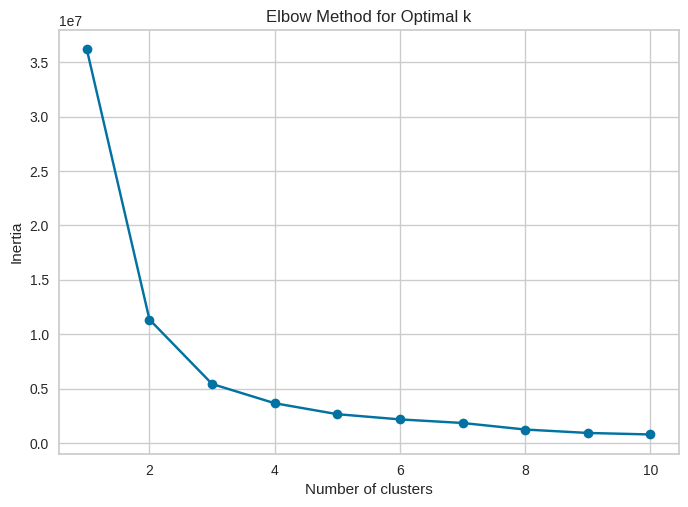

In [ ]:
# prompt: for df_train_false clusterize the dataset and grab 20 random samples from each cluster to add to df_train_resampled, that has all the random picked False data and all the rows where enchente is True. If there is a way to decide automatically the number of clusters, do it

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine optimal number of clusters using Elbow method
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_train_false.drop(columns=['dt', 'enchente']))
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
# Choose the optimal number of clusters (e.g., based on the elbow point)
optimal_k = 4 # Replace with your choice based on the elbow method plot

# Apply KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(df_train_false.drop(columns=['dt', 'enchente']))
df_train_false['cluster'] = kmeans.labels_

df_train_resampled = df_train[df_train.enchente == True].copy()

# Grab 20 random samples from each cluster
for cluster in range(optimal_k):
    cluster_samples = df_train_false[df_train_false['cluster'] == cluster]
    samples_to_add = cluster_samples.sample(n=min(20, len(cluster_samples)), random_state=42)
    df_train_resampled = pd.concat([df_train_resampled, samples_to_add])

# Remove the cluster column
df_train_resampled = df_train_resampled.drop(columns=['cluster'], errors='ignore')

In [ ]:
df_train_resampled.enchente.value_counts()

,count
enchente,
False,80
True,65


In [ ]:
X = df_train_resampled.drop(columns=["dt"])
X_test = df_test.drop(columns=["dt"])

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4082,0.3737,0.7273,0.4103,0.5246,-0.1163,-0.1537
1,0.5833,0.5612,0.5455,0.5455,0.5455,0.1608,0.1608
2,0.4583,0.4965,0.5714,0.4138,0.4800,-0.0558,-0.0590
Mean,0.4833,0.4771,0.6147,0.4565,0.5167,-0.0038,-0.0173
Std,0.0737,0.0777,0.0803,0.0629,0.0273,0.1190,0.1318


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [ ]:
setup(data=X, target="enchente", session_id=123, fix_imbalance=False, fold=3, imputation_type=None, test_data=X_test)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(508, 6)"
4,Transformed data shape,"(508, 6)"
5,Transformed train set shape,"(145, 6)"
6,Transformed test set shape,"(363, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.4833,0.4771,0.6147,0.4565,0.5167,-0.0038,-0.0173,0.4767
dt,Decision Tree Classifier,0.4970,0.5035,0.5678,0.4585,0.4995,0.0088,0.0014,0.0267
xgboost,Extreme Gradient Boosting,0.4630,0.4273,0.5693,0.4348,0.4911,-0.0498,-0.0646,0.0633
rf,Random Forest Classifier,0.4347,0.4352,0.5527,0.4042,0.4664,-0.1053,-0.1124,0.1967
knn,K Neighbors Classifier,0.4001,0.4036,0.5851,0.3879,0.4662,-0.1570,-0.1750,0.0467
et,Extra Trees Classifier,0.4694,0.4474,0.5072,0.4252,0.4620,-0.0534,-0.0556,0.1700
gbc,Gradient Boosting Classifier,0.4484,0.4301,0.4921,0.4047,0.4402,-0.0934,-0.0979,0.1133
lr,Logistic Regression,0.5651,0.5169,0.3874,0.5538,0.4337,0.1044,0.1188,0.0333
qda,Quadratic Discriminant Analysis,0.4695,0.4688,0.4336,0.4942,0.4212,-0.0522,-0.0461,0.0267
ridge,Ridge Classifier,0.5444,0.5082,0.3716,0.5198,0.4151,0.0636,0.0731,0.0233


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Verifica clusters

* Para os dados do cemaden_daily (com agregados novos), faz n clusters (cotovelo)
* Verifica se algum cluster tem correlação maior com enchentes
* Verifica distribuição usando plotly scatter 3D

In [ ]:
df_dm_enchentes.columns

Index(['chuva_total', 'chuva_max_1h', 'chuva_max_3h', 'horas_com_chuva',
       'horas_intensas_10mm', 'dt', 'enchente', 'cluster'],
      dtype='object')

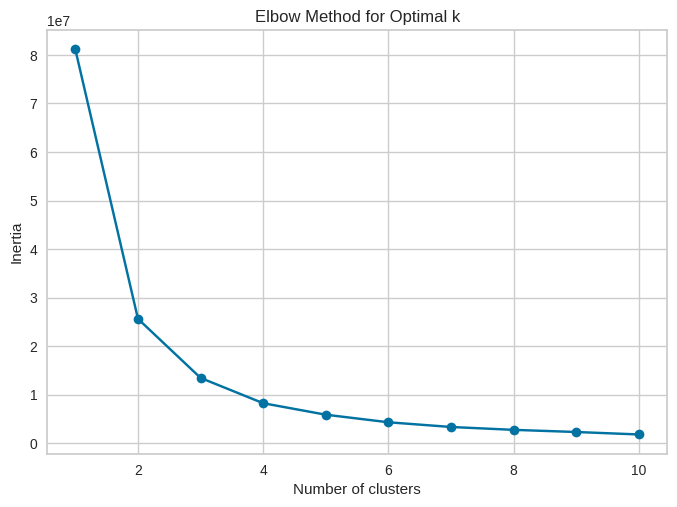

In [ ]:
import matplotlib.pyplot as plt
# Determine optimal number of clusters using Elbow method
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_dm_enchentes.drop(columns=['dt', 'enchente']))
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Choose the optimal number of clusters (e.g., based on the elbow point)
optimal_k = 2  # Replace with your choice based on the elbow method plot

# Apply KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(df_dm_enchentes.drop(columns=['dt', 'enchente']))
df_dm_enchentes['cluster'] = kmeans.labels_


cluster  enchente
0        False       1416
         True          36
1        False        134
         True          40
Name: count, dtype: int64


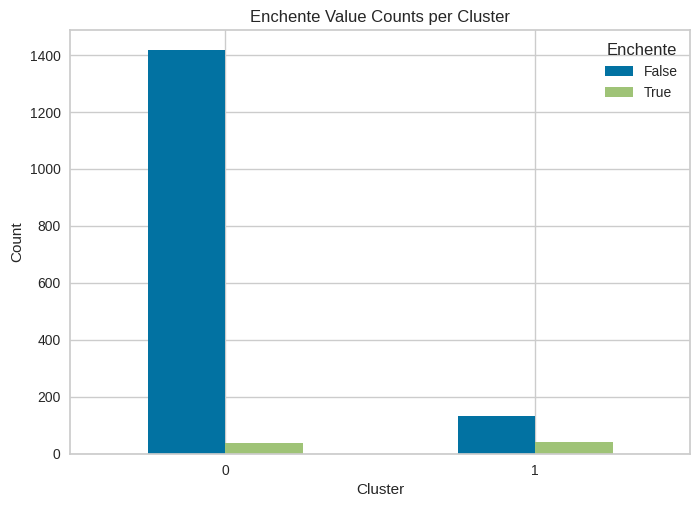

In [ ]:
# prompt: show the value counts of enchente for each cluster

# Assuming df_dm_enchentes is already created as in your provided code.
# You'll need to ensure the 'cluster' column is present in your DataFrame.
# If not, re-run the KMeans clustering part of your code.

# Group by cluster and count the occurrences of 'enchente'
cluster_enchente_counts = df_dm_enchentes.groupby('cluster')['enchente'].value_counts()

# Print the value counts
print(cluster_enchente_counts)

# For a more visual representation:
# Unstack the multi-index series for easier plotting/analysis
cluster_enchente_counts_unstacked = cluster_enchente_counts.unstack()

# Optionally, plot the results using a bar chart
import matplotlib.pyplot as plt
cluster_enchente_counts_unstacked.plot(kind='bar')
plt.title('Enchente Value Counts per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0) # Rotate x-axis labels for better readability
plt.legend(title='Enchente')
plt.show()


In [ ]:
# prompt: use plotly 3D scatter to check the distribution with cluster as the color. The 3 axis should be "enchente", "chuva_total" and "chuva_max_1h"

fig = px.scatter_3d(df_dm_enchentes, x='horas_intensas_10mm', y='chuva_total', z='chuva_max_3h', color='enchente')
fig.show()


In [ ]:
df_dm_enchentes.columns

Index(['chuva_total', 'chuva_max_1h', 'chuva_max_3h', 'horas_com_chuva',
       'horas_intensas_10mm', 'dt', 'enchente'],
      dtype='object')

# Divide dados por bacia

* A principio apenas uma bacia (tam_central)
* Filtra df_daily_metrics para ter apenas as estacoes que batem com aquela bacia
* Valida os dados de enchente vendo as metricas de chuva no dia. Serao desconsiderados dias com pouca chuva registrada nas estacoes mesmo que o label seja true
* Consolida um dataset para enchentes em tam_central com os dados cemaden


In [ ]:
tamanduatei_central = [
    "Cidade São Jorge",
    "Jardim Ipanema",
    "Paraíso",
    "Parque das Nações",
    "Santa Terezinha",
    "Vila Bastos",
    "Vila João Ramalho",
    "Vila Suiça",
    "Vila Vitória",
]

In [ ]:
df_dm_tam_central = df_daily_metrics[df_daily_metrics["nomeEstacao"].isin(tamanduatei_central)].copy()

In [ ]:
df_dm_tam_central.columns

Index(['nomeEstacao', 'latitude', 'longitude', 'ano', 'mes', 'dia',
       'chuva_total', 'chuva_max_1h', 'chuva_max_3h', 'horas_com_chuva',
       'horas_intensas_10mm', 'perc_chuva_em_3h', 'coef_var'],
      dtype='object')

In [ ]:
df_dm_tc_grouped = df_dm_tam_central.groupby(["ano", "mes", "dia"]).agg({
    "chuva_total": "sum",
    "chuva_max_1h": "max",
    "chuva_max_3h": "max",
    "horas_com_chuva": "max",
    "horas_intensas_10mm": "max",
  }).reset_index()

In [ ]:
df_dm_tc_dt = df_dm_tc_grouped.copy()
df_dm_tc_dt['dt'] = pd.to_datetime(df_dm_tc_dt.apply(lambda row: f"{int(row['dia']):02}/{int(row['mes']):02}/{int(row['ano'])}", axis=1), dayfirst=True)
df_dm_tc_dt.drop(columns=["ano", "mes", "dia"], inplace=True)

In [ ]:
df_dm_tc_sazonal = df_dm_tc_dt[~df_dm_tc_dt["dt"].dt.month.between(5, 10)].copy()

In [ ]:
df_tc_enchentes = df_dm_tc_sazonal.copy()
df_tc_enchentes['enchente'] = df_tc_enchentes['dt'].isin(df_enchentes_verificados['dt'])

Remove dias com nenhuma chuva

In [ ]:
# prompt: from df_tc_enchentes change every label where enchentes is true but any of chuva_total, chuva_max_1h, chuva_max_3h, horas_com_chuva is less than or equal to a threshold. The threshold needs to be different for every feature, so make it a dict. Print how many labels were changed. Create a new df for this (df_tc_enchentes_cut)

# Define the thresholds for each feature
thresholds = {
    'chuva_total': 0,
    'chuva_max_1h': 10,
    'chuva_max_3h': 0,
    'horas_com_chuva': 0
}

# Create a copy of the DataFrame to avoid modifying the original
df_tc_enchentes_cut = df_tc_enchentes.copy()

# Initialize a counter for the number of labels changed
labels_changed = 0

# Iterate through the DataFrame
for index, row in df_tc_enchentes.iterrows():
    # Check if 'enchente' is True
    if row['enchente']:
        # Check if any of the specified features are below the threshold
        for feature, threshold in thresholds.items():
            if row[feature] <= threshold:
                # Change the 'enchente' label to False
                df_tc_enchentes_cut.loc[index, 'enchente'] = False
                labels_changed += 1
                break  # Exit the inner loop once a threshold is met

# Print the number of labels changed
print(f"{labels_changed} labels were changed.")


23 labels were changed.


# Testa modelo Tam central

* Usa dataset cemaden atualizado com apenas estacoes tam central
* Usa undersampling por clusters
* Usa agregados novos


**Considerando threshold de 0**

| **True Class \ Predicted Class** | **False** | **True** |
| -------------------------------- | :-------: | :------: |
| **False**                        |    293    |    59    |
| **True**                         |     3     |     8    |

Modelo LGBM

| **Fold** | **Accuracy** |   **AUC**  | **Recall** |  **Prec.** |   **F1**   |  **Kappa** |   **MCC**   |
| :------: | :----------: | :--------: | :--------: | :--------: | :--------: | :--------: | :---------: |
|     0    |    0.3696    |   0.3298   |   0.6500   |   0.3714   |   0.4727   |   -0.1805  |   -0.2280   |
|     1    |    0.5870    |   0.6163   |   0.7000   |   0.5185   |   0.5957   |   0.1922   |    0.2014   |
|     2    |    0.5000    |   0.5029   |   0.5500   |   0.4400   |   0.4889   |   0.0112   |    0.0115   |
| **Mean** |  **0.4855**  | **0.4830** | **0.6333** | **0.4433** | **0.5191** | **0.0076** | **-0.0050** |
|  **Std** |    0.0893    |   0.1178   |   0.0624   |   0.0601   |   0.0546   |   0.1522   |    0.1757   |

**Considerando thresholds acima de 0**

| **True Class \ Predicted Class** | **False** | **True** |
| -------------------------------- | :-------: | :------: |
| **False**                        |    329    |    23    |
| **True**                         |     3     |     8    |

| **Fold** | **Accuracy** |   **AUC**  | **Recall** |  **Prec.** |   **F1**   |  **Kappa** |   **MCC**  |
| :------: | :----------: | :--------: | :--------: | :--------: | :--------: | :--------: | :--------: |
|     0    |    0.7857    |   0.9123   |   0.5000   |   0.8889   |   0.6400   |   0.5039   |   0.5462   |
|     1    |    0.7381    |   0.7981   |   0.6875   |   0.6471   |   0.6667   |   0.4513   |   0.4519   |
|     2    |    0.4878    |   0.5128   |   0.6000   |   0.3750   |   0.4615   |   0.0205   |   0.0226   |
| **Mean** |  **0.6705**  | **0.7411** | **0.5958** | **0.6370** | **0.5894** | **0.3252** | **0.3402** |
|  **Std** |    0.1307    |   0.1680   |   0.0766   |   0.2099   |   0.0911   |   0.2166   |   0.2279   |




In [ ]:
df_test = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year >= 2023]
df_train = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year < 2023]

In [ ]:
df_train_false = df_train[df_train.enchente == False]
df_train_true = df_train[df_train.enchente == True]

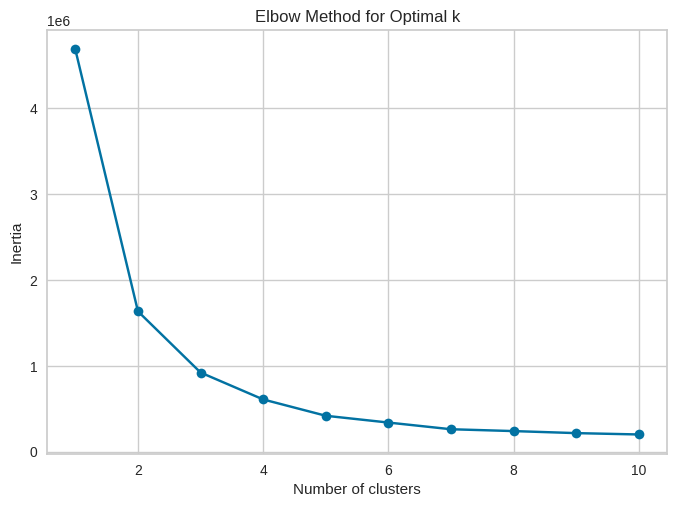

In [ ]:
# prompt: for df_train_false clusterize the dataset and grab 20 random samples from each cluster to add to df_train_resampled, that has all the random picked False data and all the rows where enchente is True. If there is a way to decide automatically the number of clusters, do it

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine optimal number of clusters using Elbow method
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_train_false.drop(columns=['dt', 'enchente']))
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
# Choose the optimal number of clusters (e.g., based on the elbow point)
optimal_k = 4 # Replace with your choice based on the elbow method plot

# Apply KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(df_train_false.drop(columns=['dt', 'enchente']))
df_train_false['cluster'] = kmeans.labels_

df_train_resampled = df_train[df_train.enchente == True].copy()

# Grab 20 random samples from each cluster
for cluster in range(optimal_k):
    cluster_samples = df_train_false[df_train_false['cluster'] == cluster]
    samples_to_add = cluster_samples.sample(n=min(20, len(cluster_samples)), random_state=42)
    df_train_resampled = pd.concat([df_train_resampled, samples_to_add])

# Remove the cluster column
df_train_resampled = df_train_resampled.drop(columns=['cluster'], errors='ignore')

In [ ]:
df_train_resampled.enchente.value_counts()

,count
enchente,
False,78
True,47


In [ ]:
X = df_train_resampled.drop(columns=["dt"])
X_test = df_test.drop(columns=["dt"])

In [ ]:
setup(data=X, target="enchente", session_id=123, fix_imbalance=False, fold=3, imputation_type=None, test_data=X_test)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(488, 6)"
4,Transformed data shape,"(488, 6)"
5,Transformed train set shape,"(125, 6)"
6,Transformed test set shape,"(363, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.6705,0.7411,0.5958,0.6370,0.5894,0.3252,0.3402,0.1633
gbc,Gradient Boosting Classifier,0.6307,0.7273,0.5958,0.5552,0.5604,0.2554,0.2589,0.1233
nb,Naive Bayes,0.6382,0.7822,0.4917,0.6869,0.5222,0.2522,0.2838,0.0233
dt,Decision Tree Classifier,0.6148,0.6007,0.5347,0.5568,0.5194,0.2131,0.2229,0.0233
xgboost,Extreme Gradient Boosting,0.6067,0.6929,0.5333,0.5356,0.5159,0.1987,0.2016,0.0600
qda,Quadratic Discriminant Analysis,0.6063,0.7049,0.4694,0.5714,0.4819,0.1835,0.1924,0.0267
svm,SVM - Linear Kernel,0.5105,0.6238,0.6153,0.4029,0.4672,0.0583,0.0745,0.0233
rf,Random Forest Classifier,0.5828,0.6928,0.4708,0.5201,0.4579,0.1366,0.1485,0.1933
lr,Logistic Regression,0.6065,0.7199,0.4083,0.6869,0.4145,0.1602,0.2054,2.3433
ridge,Ridge Classifier,0.6065,0.7182,0.4083,0.6869,0.4145,0.1602,0.2054,0.0233


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7857,0.9123,0.5000,0.8889,0.6400,0.5039,0.5462
1,0.7381,0.7981,0.6875,0.6471,0.6667,0.4513,0.4519
2,0.4878,0.5128,0.6000,0.3750,0.4615,0.0205,0.0226
Mean,0.6705,0.7411,0.5958,0.6370,0.5894,0.3252,0.3402
Std,0.1307,0.1680,0.0766,0.2099,0.0911,0.2166,0.2279


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Testa undersampling c/ k alto

* Modelo TAM Central
* Valor de k alto -> 40?


In [ ]:
df_test = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year >= 2023].copy()
df_train = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year < 2023].copy()

df_train_resampled = cluster_undersample(df_train, target_column='enchente', resample_strength=20, samples_per_cluster=2)

print("\nResampled training data value counts:")
print(df_train_resampled['enchente'].value_counts())

Number of true instances: 47
Desired number of false instances: 60
Calculated number of clusters: 30
Samples per cluster: 2

Resampled training data value counts:
enchente
False    57
True     47
Name: count, dtype: int64


In [ ]:
X = df_train_resampled.drop(columns=["dt"])
X_test = df_test.drop(columns=["dt"])

In [ ]:
setup(data=X, target="enchente", session_id=123, fix_imbalance=False, fold=3, imputation_type=None, test_data=X_test)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(467, 6)"
4,Transformed data shape,"(467, 6)"
5,Transformed train set shape,"(104, 6)"
6,Transformed test set shape,"(363, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.6922,0.6387,0.6153,0.6802,0.6440,0.3733,0.3766,0.0267
lda,Linear Discriminant Analysis,0.6922,0.6387,0.6153,0.6802,0.6440,0.3733,0.3766,0.0300
lr,Logistic Regression,0.6731,0.6389,0.6153,0.6519,0.6302,0.3370,0.3396,0.1133
lightgbm,Light Gradient Boosting Machine,0.6336,0.6431,0.5931,0.6056,0.5921,0.2603,0.2671,0.1933
nb,Naive Bayes,0.6246,0.7004,0.5736,0.6016,0.5735,0.2409,0.2514,0.0267
ada,Ada Boost Classifier,0.5762,0.6352,0.5944,0.5294,0.5597,0.1547,0.1553,0.1167
qda,Quadratic Discriminant Analysis,0.6050,0.6309,0.5500,0.5583,0.5532,0.1989,0.1991,0.0233
et,Extra Trees Classifier,0.5961,0.5875,0.5542,0.5581,0.5532,0.1859,0.1876,0.2033
xgboost,Extreme Gradient Boosting,0.5866,0.6534,0.5722,0.5439,0.5496,0.1681,0.1737,0.0900
gbc,Gradient Boosting Classifier,0.5857,0.6240,0.5514,0.5439,0.5440,0.1653,0.1679,0.1200


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6286,0.5855,0.6250,0.5882,0.6061,0.2553,0.2557
1,0.7714,0.7796,0.6875,0.7857,0.7333,0.5349,0.5385
2,0.6765,0.5509,0.5333,0.6667,0.5926,0.3297,0.3354
Mean,0.6922,0.6387,0.6153,0.6802,0.6440,0.3733,0.3766
Std,0.0594,0.1007,0.0633,0.0812,0.0634,0.1182,0.1191


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=123, solver='auto',
                tol=0.0001)

In [ ]:
predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9421,0.8381,0.7273,0.3077,0.4324,0.4072,0.4495


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label
2537,15.360000,5.710000,5.710000,2.0,0.0,False,0
2538,44.389999,24.629999,29.160000,2.0,1.0,False,0
2539,44.720001,28.950001,29.150000,4.0,1.0,False,0
2540,201.020004,10.110000,16.330000,12.0,1.0,False,0
2541,119.320000,3.730000,6.890000,24.0,0.0,False,0
...,...,...,...,...,...,...,...
3263,321.760010,24.020000,51.209999,24.0,3.0,True,1
3264,5.750000,1.380000,1.580000,9.0,0.0,False,0
3265,0.800000,0.200000,0.200000,4.0,0.0,False,0
3266,0.600000,0.200000,0.200000,3.0,0.0,False,0


In [ ]:
# prompt: predict model with best model and show me the filtered resulting df with only the false negatives

# Make predictions on the test data using the best model
predictions = predict_model(best_model, data=X_test)

# Filter the predictions DataFrame to show only False Negatives
# False Negatives are instances where the true value was True (1) but the model predicted False (0)
false_negatives_df = predictions[(predictions['enchente'] == True) & (predictions['prediction_label'] == 0)].copy()

# Print or display the filtered DataFrame
print("\nFalse Negatives:")
false_negatives_df

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9421,0.8381,0.7273,0.3077,0.4324,0.4072,0.4495



False Negatives:


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label
2567,98.940002,20.450001,21.040001,6.0,2.0,True,0
2590,147.210007,33.790001,34.980000,17.0,1.0,True,0
2863,75.949997,11.210000,11.630000,12.0,1.0,True,0


In [ ]:
# prompt: now with the same predictions grab 3 random true positives

# Filter the predictions DataFrame to show only True Positives
# True Positives are instances where the true value was True (1) and the model predicted True (1)
true_positives_df = predictions[(predictions['enchente'] == True) & (predictions['prediction_label'] == 1)].copy()

# Randomly sample 3 true positives
random_true_positives = true_positives_df.sample(n=min(3, len(true_positives_df)))

# Print or display the sampled true positives
print("\n3 Random True Positives:")
random_true_positives


3 Random True Positives:


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label
2934,171.850006,34.330002,35.709999,3.0,2.0,True,1
2551,209.830002,29.480000,50.680000,5.0,2.0,True,1
2920,197.300003,28.020000,42.200001,10.0,2.0,True,1


In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Testa novo agregado de máximo

* Em vez de pegar apenas o valor máximo, pega a média entre os 2 ou 3 maiores valores entre as estações.
* Testa com modelo TC e undersampling c/ k alto

In [ ]:
def agg_avg_top_n(n):
  """
  Creates a function to calculate the average of the top n values in a pandas Series.
  This is intended for use with the pandas .agg() method.

  Args:
    n (int): The number of top values to consider for the average.

  Returns:
    function: A function that takes a pandas Series and returns the average of its top n values.
  """
  def avg_top_n(series):
    if series.empty:
      return np.nan
    # Sort in descending order and take the top n values
    top_values = series.nlargest(n)
    return top_values.mean()
  # Give the function a more descriptive name for clarity when used in agg
  avg_top_n.__name__ = f'avg_top_{n}'
  return avg_top_n

In [ ]:
tamanduatei_central = [
    "Cidade São Jorge",
    "Jardim Ipanema",
    "Paraíso",
    "Parque das Nações",
    "Santa Terezinha",
    "Vila Bastos",
    "Vila João Ramalho",
    "Vila Suiça",
    "Vila Vitória",
]

In [ ]:
df_dm_tam_central = df_daily_metrics[df_daily_metrics["nomeEstacao"].isin(tamanduatei_central)].copy()

In [ ]:
df_dm_tc_grouped = df_dm_tam_central.groupby(["ano", "mes", "dia"]).agg({
    "chuva_total": "sum",
    "chuva_max_1h": agg_avg_top_n(3),
    "chuva_max_3h": agg_avg_top_n(3),
    "horas_com_chuva": agg_avg_top_n(3),
    "horas_intensas_10mm": agg_avg_top_n(3),}).reset_index()

In [ ]:
df_dm_tc_dt = df_dm_tc_grouped.copy()
df_dm_tc_dt['dt'] = pd.to_datetime(df_dm_tc_dt.apply(lambda row: f"{int(row['dia']):02}/{int(row['mes']):02}/{int(row['ano'])}", axis=1), dayfirst=True)
df_dm_tc_dt.drop(columns=["ano", "mes", "dia"], inplace=True)

In [ ]:
df_dm_tc_sazonal = df_dm_tc_dt[~df_dm_tc_dt["dt"].dt.month.between(5, 10)].copy()

In [ ]:
df_tc_enchentes = df_dm_tc_sazonal.copy()
df_tc_enchentes['enchente'] = df_tc_enchentes['dt'].isin(df_enchentes_verificados['dt'])

In [ ]:
# Define the thresholds for each feature
thresholds = {
    'chuva_total': 10,
    'chuva_max_1h': 2,
    'chuva_max_3h': 6,
    'horas_com_chuva': 2
}

# Create a copy of the DataFrame to avoid modifying the original
df_tc_enchentes_cut = df_tc_enchentes.copy()

# Initialize a counter for the number of labels changed
labels_changed = 0

# Iterate through the DataFrame
for index, row in df_tc_enchentes.iterrows():
    # Check if 'enchente' is True
    if row['enchente']:
        # Check if any of the specified features are below the threshold
        for feature, threshold in thresholds.items():
            if row[feature] <= threshold:
                # Change the 'enchente' label to False
                df_tc_enchentes_cut.loc[index, 'enchente'] = False
                labels_changed += 1
                break  # Exit the inner loop once a threshold is met

# Print the number of labels changed
print(f"{labels_changed} labels were changed.")


16 labels were changed.


In [ ]:
df_test = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year >= 2023].copy()
df_train = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year < 2023].copy()

df_train_resampled = cluster_undersample(df_train, target_column='enchente', resample_strength=20, samples_per_cluster=2)

print("\nResampled training data value counts:")
print(df_train_resampled['enchente'].value_counts())

Number of true instances: 49
Desired number of false instances: 60
Calculated number of clusters: 30
Samples per cluster: 2

Resampled training data value counts:
enchente
False    58
True     49
Name: count, dtype: int64


In [ ]:
X = df_train_resampled.drop(columns=["dt"])
X_test = df_test.drop(columns=["dt"])

In [ ]:
setup(data=X, target="enchente", session_id=123, fix_imbalance=False, fold=3, imputation_type=None, test_data=X_test)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(470, 6)"
4,Transformed data shape,"(470, 6)"
5,Transformed train set shape,"(107, 6)"
6,Transformed test set shape,"(363, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.6725,0.7001,0.6716,0.6324,0.6500,0.3419,0.3441,0.0533
lr,Logistic Regression,0.6815,0.7403,0.6115,0.6731,0.6396,0.3544,0.3571,2.6200
ridge,Ridge Classifier,0.6815,0.7445,0.5919,0.6875,0.6339,0.3532,0.3589,0.0267
lda,Linear Discriminant Analysis,0.6815,0.7444,0.5919,0.6875,0.6339,0.3532,0.3589,0.0267
nb,Naive Bayes,0.7005,0.7194,0.5478,0.7778,0.6219,0.3826,0.4142,0.0467
ada,Ada Boost Classifier,0.6257,0.6646,0.6078,0.5804,0.5891,0.2437,0.2495,0.1100
xgboost,Extreme Gradient Boosting,0.6077,0.6377,0.5907,0.5708,0.5792,0.2107,0.2117,0.0700
qda,Quadratic Discriminant Analysis,0.6534,0.6874,0.4890,0.6901,0.5678,0.2876,0.3048,0.0300
rf,Random Forest Classifier,0.6069,0.6071,0.5466,0.5758,0.5506,0.2005,0.2082,0.2200
et,Extra Trees Classifier,0.5886,0.5969,0.5306,0.5542,0.5421,0.1682,0.1685,0.1800


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6944,0.7090,0.7647,0.6500,0.7027,0.3926,0.3981
1,0.6944,0.6891,0.6875,0.6471,0.6667,0.3851,0.3857
2,0.6286,0.7023,0.5625,0.6000,0.5806,0.2479,0.2483
Mean,0.6725,0.7001,0.6716,0.6324,0.6500,0.3419,0.3441
Std,0.0311,0.0083,0.0833,0.0229,0.0512,0.0665,0.0679


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [ ]:
predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9339,0.8116,0.6364,0.2593,0.3684,0.3400,0.3786


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label,prediction_score
2537,15.360000,3.940000,3.940000,2.000000,0.000000,False,0,0.8543
2538,44.389999,12.556666,14.200000,2.000000,0.666667,False,0,0.6769
2539,44.720001,11.553333,11.883333,3.000000,0.333333,False,0,0.7678
2540,201.020004,8.153334,15.893333,10.666667,0.333333,False,0,0.6264
2541,119.320000,3.273333,6.426667,21.666666,0.000000,False,0,0.8623
...,...,...,...,...,...,...,...,...
3263,321.760010,21.963333,45.973331,16.666666,2.666667,True,1,0.7791
3264,5.750000,0.983333,1.053333,4.666667,0.000000,False,0,0.8748
3265,0.800000,0.066667,0.066667,1.333333,0.000000,False,0,0.8543
3266,0.600000,0.066667,0.066667,1.000000,0.000000,False,0,0.8543


In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
df_enchentes_verificados.ano.unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [ ]:
df_enchentes_verificados.shape

(79, 5)

In [ ]:
df_enchentes_verificados.query("ano >= 2023").shape

(13, 5)

In [ ]:
df_dm_enchentes.head()

,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,dt,enchente
0,69.32,46.63,69.32,36.0,0.0,2016-01-01,False
1,170.39,58.83,89.43,170.0,0.0,2016-01-02,False
2,28.62,9.89,16.23,70.0,0.0,2016-01-03,False
3,0.80,0.40,0.40,4.0,0.0,2016-01-04,False
4,0.00,0.00,0.00,0.0,0.0,2016-01-05,False


In [ ]:
df_dm_enchentes.query('chuva_total > 3').chuva_total.describe()

,chuva_total
count,1218.000000
mean,162.789335
std,242.544395
min,3.000000
25%,15.627500
50%,59.320000
75%,205.677500
max,2138.710000


In [ ]:
df_dm_enchentes.query('chuva_total > 15').shape

(922, 7)

Definição de chuva moderada: entre 2.5 10 mm/h
chuva fraca: < 2.5
chuva forte: 10 - 50
muito forte / violenta : 50+

In [ ]:
df_dm_enchentes.query('chuva_max_1h > 50').enchente.value_counts()

,count
enchente,
False,398
True,57


# Valida enchente por endereço de chamado

In [ ]:
import unicodedata

def strip_accents(s):
    """
    Remove accent marks and diacritics from a string using Unicode normalization.

    This function decomposes the input string using NFD Unicode normalization and
    removes all combining character markers (accent/diacritic marks) to return
    a simplified ASCII-friendly version of the text.

    Parameters:
    ----------
    s : str
        The input string containing potential accented characters or diacritics.

    Returns:
    -------
    str
        The processed string with accent marks removed while preserving original characters.
    """
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                  if unicodedata.category(c) != 'Mn')


def rename_neighborhood_list(name_list):
    """
    Standardize neighborhood names by converting to uppercase, replacing common terms,
    and removing accents.

    This function processes a list of neighborhood names by:
    1. Converting all characters to uppercase
    2. Replacing common prefixes with abbreviations (VILA → VL, JARDIM → JD, etc.)
    3. Stripping accent marks using the strip_accents utility
    4. Modifies AND returns the input list object (operates in-place)

    Parameters:
    ----------
    name_list : list[str]
        A list of neighborhood name strings to be standardized in-place.

    Returns:
    -------
    list[str]
        The modified input list containing standardized neighborhood names. Common
        replacements include:
        - "VILA" becomes "VL"
        - "JARDIM" becomes "JD"
        - "PARQUE" becomes "PQ"

    Note:
    -----
    This function modifies the original list object while returning it. Consider making
    a copy if the original list needs to be preserved.
    """
    for i, name in enumerate(name_list):
        name_list[i] = strip_accents(name.upper().replace("VILA", "VL").replace("JARDIM", "JD").replace("PARQUE", "PQ"))
    return name_list


In [ ]:
def prepare_basin_df(basin_list):
  df_chamados_neigh = df_chamados.copy()
  df_chamados_neigh['bairro'] = df_chamados_neigh['end'].str.extract(r'-\s*([A-Z\s]+)$')
  df_chamados_basin = df_chamados_neigh[df_chamados_neigh['bairro'].isin(basin_list)].drop(columns=['bairro', 'end'])
  return df_chamados_basin.copy()

In [ ]:
file_chamados = 'df_chamados_defciv.csv'
grab_from_gdrive('1Fa5TOO-hXAT4l7-IyA51Kswjdxn7WoQD', file_chamados)
df_chamados = pd.read_csv(file_chamados)

Downloading...
From: https://drive.google.com/uc?id=1Fa5TOO-hXAT4l7-IyA51Kswjdxn7WoQD
To: /content/df_chamados_defciv.csv
100%|██████████| 9.08M/9.08M [00:00<00:00, 43.4MB/s]


In [ ]:
df_chamados.rename(
    columns={
        "ENDEREÇO": "end",
        "DATA": "dt",
        "SERVIÇO": "serv",
        "ENCAMINHAMENTO": "enc",
        "SOLICITANTE": "solic"
        }
    )

,serv,end,dt,enc,solic
0,811.4 - DDC - Deslizamento / Escorregamento / ...,"RUA BRAUNA, 6 - VL VITORIA",14/10/2005,DMO,CONTRAL
1,811.4 - DDC - Deslizamento / Escorregamento / ...,"RUA BRAUNA, 16 - VL VITORIA",14/10/2005,DMO,LUIZ SERGIO
2,802 - DPDCSA - Vistoria de Árvores (Código sub...,"RUA SAGUI DA SERRA, 578 - RECREIO DA BORDA DO",15/10/2005,NaN,SUELI APRECIDA BELO
3,810.2 - DDC - Muro - Ameaça de Queda,"RUA HUMBERTO DE CAMPOS, 90 - VL ALZIRA",31/07/2003,DDC,CON. RESID. VL ASSUNCÃO // PATRICIA WANDEUR
4,811 - DDC - Deslizamento / Escorregamento / De...,RUA LOBO GUARA - RECREIO DA BORDA DO,27/01/2005,DGA.,CELSO - GEPLAN
...,...,...,...,...,...
67697,826 - DPDCSA - Vistoria de Árvore - Área Interna,"EST CATA PRETA, 826 - VL JOAO RAMALHO",15/09/2023,DMAV,CRECHE PROF. HIDEKI KOYAMA
67698,818 - DDC - Participação em Evento,"RUA IGARAPAVA, 250 - VL VALPARAISO",30/08/2023,DPDC,DEPARTAMENTO DE PROTEÇÃO E DEFESA CIVIL
67699,801.2 - DDC - Vistoria Edificação - Casa,"EST LESTE, DO - BAIRRO INEXISTENTE",15/09/2023,DGPPA,MARCIO ANTONIO CAMPOS
67700,802.5 - DDC - Vistoria em Árvores - Vistoria,"AVN AYRTON SENNA DA SILVA, 534 - JD ALZIRA FRANCO",13/09/2023,DMAV,EMEIEF PROFESSORA SANDRA CRISTINA


In [ ]:
tamanduatei_central = ["Campestre", "Santa Maria", "Jardim", "Vila Alpina",
"Vila Guiomar", "Vila Alice", "Vila Bastos", "Jardim Bela Vista", "Centro",
"Casa Branca", "Vila Gilda", "Paraíso", "Vila Assunção", "Vila Alzira",
"Silveira", "Vila Linda", "Vila Helena", "Jardim do Estádio",
"Jardim Santa Cristina", "Jardim Guarará", "Sítio dos Vianas",
"Jardim Cipreste", "Jardim Irene", "Vila João Ramalho", "Jardim Vila Rica",
"Cata Preta", "Jardim Santo André CDHU", "Jardim Santo André CDHU",
"Vila Luzita", "Jardim Telles de Menezes", "Vila Suiça", "Condomínio Maracanã",
"Vila Lutécia", "Vila Tibiriça", "Vila Vitória", "Jardim Ipanema",
"Vila Guaraciaba", "Vila Progresso", "Parque Gerassi", "Cidade São Jorge",
"Centreville", "Vila Guarani", "Vila Humaitá", "Parque Marajoara",
"Vila Homero Thon", "Vila América", "Vila Pires", "Silveira", "Vila Alzira",
"Novo Homero Thon", "Várzea do Tamanduateí", "Jardim Alzira Franco",
"Parque Jaçatuba", "Vila Curuça", "Bangú", "Parque das Nações",
"Santa Terezinha", "Vila Francisco Matarazzo", "Jardim Santo Antônio",
"Vila Camilópolis", "Vila Metalúrgica"]

tamanduatei_central_renamed = rename_neighborhood_list(tamanduatei_central)

In [ ]:
df_chamados_tamanduatei_central = prepare_basin_df(tamanduatei_central_renamed)
df_chamados_tamanduatei_central_unique = df_chamados_tamanduatei_central.drop_duplicates(subset=['dt']).reset_index(drop=True)

KeyError: 'end'

# Testa modelo para pancadas de chuva

In [ ]:
df_tc_enchentes_cut_max = df_tc_enchentes.query('chuva_max_1h > 10')

,count
enchente,
False,270
True,53


In [ ]:
df_test = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year >= 2022].copy()
df_train = df_tc_enchentes_cut[df_tc_enchentes_cut['dt'].dt.year < 2022].copy()

df_train_resampled = cluster_undersample(df_train, target_column='enchente', resample_strength=20, samples_per_cluster=2)

print("\nResampled training data value counts:")
print(df_train_resampled['enchente'].value_counts())

Number of true instances: 35
Desired number of false instances: 52
Calculated number of clusters: 26
Samples per cluster: 2

Resampled training data value counts:
enchente
False    50
True     35
Name: count, dtype: int64


In [ ]:
df_test.enchente.value_counts()

,count
enchente,
False,526
True,18


In [ ]:
X = df_train_resampled.drop(columns=["dt"])
X_test = df_test.drop(columns=["dt"])

In [ ]:
setup(data=X, target="enchente", session_id=123, fix_imbalance=False, fold=3, imputation_type=None, test_data=X_test)

,Description,Value
0,Session id,123
1,Target,enchente
2,Target type,Binary
3,Original data shape,"(629, 6)"
4,Transformed data shape,"(629, 6)"
5,Transformed train set shape,"(85, 6)"
6,Transformed test set shape,"(544, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_model = compare_models(n_select=1, sort="Prec.")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7410,0.7831,0.6843,0.6936,0.6813,0.4648,0.4727,0.2667
ridge,Ridge Classifier,0.6720,0.7867,0.5152,0.6794,0.5705,0.3121,0.3311,0.0267
lda,Linear Discriminant Analysis,0.6720,0.7901,0.5152,0.6794,0.5705,0.3121,0.3311,0.0233
lr,Logistic Regression,0.6946,0.7833,0.5985,0.6733,0.6082,0.3650,0.3880,0.0533
xgboost,Extreme Gradient Boosting,0.7069,0.7476,0.6591,0.6535,0.6521,0.4003,0.4036,0.0433
nb,Naive Bayes,0.7180,0.7726,0.7172,0.6491,0.6704,0.4282,0.4412,0.0233
ada,Ada Boost Classifier,0.6938,0.7695,0.6288,0.6310,0.6241,0.3681,0.3727,0.1033
gbc,Gradient Boosting Classifier,0.6827,0.7690,0.6010,0.6238,0.6092,0.3430,0.3454,0.1033
et,Extra Trees Classifier,0.6704,0.7034,0.5682,0.6051,0.5842,0.3118,0.3138,0.1667
dt,Decision Tree Classifier,0.6720,0.6743,0.6869,0.6013,0.6380,0.3434,0.3465,0.0233


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
create_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7586,0.7598,0.8333,0.6667,0.7407,0.5201,0.5315
1,0.7500,0.7578,0.5833,0.7778,0.6667,0.4731,0.4857
2,0.7143,0.8316,0.6364,0.6364,0.6364,0.4011,0.4011
Mean,0.7410,0.7831,0.6843,0.6936,0.6813,0.4648,0.4727
Std,0.0192,0.0343,0.1076,0.0608,0.0438,0.0489,0.0540


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [ ]:
predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9430,0.9441,0.6111,0.3143,0.4151,0.3884,0.4122


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label,prediction_score
2172,23.370001,3.370000,3.770000,13.0,0.0,False,0,0.9251
2173,50.590000,11.650000,16.969999,8.0,1.0,False,0,0.9879
2174,294.149994,49.580002,56.980000,17.0,2.0,True,1,0.7357
2175,187.130005,27.080000,30.430000,10.0,1.0,False,1,0.8132
2176,74.129997,22.000000,22.000000,5.0,1.0,False,0,0.7210
...,...,...,...,...,...,...,...,...
3263,321.760010,24.020000,51.209999,24.0,3.0,True,1,0.8935
3264,5.750000,1.380000,1.580000,9.0,0.0,False,0,0.9879
3265,0.800000,0.200000,0.200000,4.0,0.0,False,0,0.9832
3266,0.600000,0.200000,0.200000,3.0,0.0,False,0,0.9832


In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# prompt: predict model with best model and show me the filtered resulting df with only the false negatives

# Make predictions on the test data using the best model
predictions = predict_model(best_model, data=X_test)

# Filter the predictions DataFrame to show only False Negatives
# False Negatives are instances where the true value was True (1) but the model predicted False (0)
false_negatives_df = predictions[(predictions['enchente'] == True) & (predictions['prediction_label'] == 0)].copy()

# Print or display the filtered DataFrame
print("\nFalse Negatives:")
false_negatives_df

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9421,0.8381,0.7273,0.3077,0.4324,0.4072,0.4495



False Negatives:


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label
2567,98.940002,20.450001,21.040001,6.0,2.0,True,0
2590,147.210007,33.790001,34.980000,17.0,1.0,True,0
2863,75.949997,11.210000,11.630000,12.0,1.0,True,0


In [ ]:
# prompt: now with the same predictions grab 3 random true positives

# Filter the predictions DataFrame to show only True Positives
# True Positives are instances where the true value was True (1) and the model predicted True (1)
true_positives_df = predictions[(predictions['enchente'] == True) & (predictions['prediction_label'] == 1)].copy()

# Randomly sample 3 true positives
random_true_positives = true_positives_df.sample(n=min(3, len(true_positives_df)))

# Print or display the sampled true positives
print("\n3 Random True Positives:")
random_true_positives


3 Random True Positives:


,chuva_total,chuva_max_1h,chuva_max_3h,horas_com_chuva,horas_intensas_10mm,enchente,prediction_label
2934,171.850006,34.330002,35.709999,3.0,2.0,True,1
2551,209.830002,29.480000,50.680000,5.0,2.0,True,1
2920,197.300003,28.020000,42.200001,10.0,2.0,True,1


In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…